In [1]:
import os
import numpy as np
from skimage import io
from matplotlib import pyplot as plt
import cv2
from skimage import color
from scipy.ndimage import binary_fill_holes
from skimage.filters import gaussian        

from skimage import exposure
from tifffile import imread, imwrite
from random import sample

In [132]:
animal = 'MD585'
BASE = f'/net/birdstore/Active_Atlas_Data/data_root/pipeline_data/{animal}/preps'
INPUT = os.path.join(BASE, 'C1/thumbnail_aligned')
OUTPUT = os.path.join(BASE, 'C1', 'thumbnail_greyscale')
os.makedirs(OUTPUT, exist_ok=True)
files = sorted(os.listdir(INPUT))
print(len(files))

446


082.tif
/net/birdstore/Active_Atlas_Data/data_root/pipeline_data/MD585/preps/C1/thumbnail_aligned/082.tif
uint8


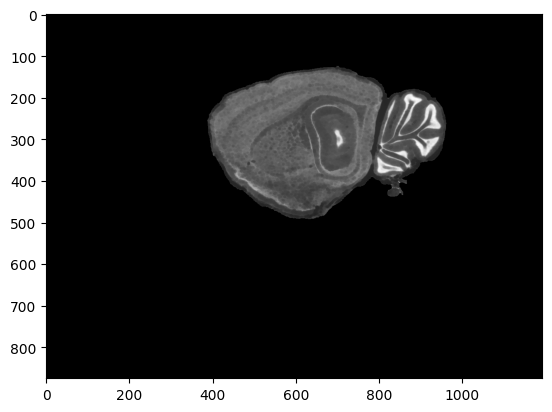

In [135]:
def mask_and_grey(image_rgb):
    # Convert RGB to grayscale
    if image_rgb.ndim == 3:
        gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    else:
        gray = image_rgb.copy()
    #gray[(gray > 230) & (gray < 235)] = 255
        
    blurred = cv2.GaussianBlur(gray, (5, 5), 1) 
    # Apply thresholding
    mask = cv2.threshold(blurred, 230, 1, cv2.THRESH_BINARY_INV)[1]
    mask = binary_fill_holes(mask)
    cleaned = cv2.bitwise_and(gray, gray, mask=mask.astype(np.uint8))
    cleaned = cv2.GaussianBlur(cleaned, (5, 5), 1) 
    cleaned *= 255 # or any coefficient
    cleaned = cleaned.astype(np.uint8)
    
    contours, hierarchy = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    for contour in contours:
        area = cv2.contourArea(contour)
        if area < 1000:
            cv2.drawContours(cleaned, contour, -1, 0, 3)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    cleaned = cv2.erode(cleaned, kernel, iterations=1)
    contours, hierarchy = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    for contour in contours:
        area = cv2.contourArea(contour)
        if area < 1000:
            cv2.drawContours(cleaned, contour, -1, 0, 3)

            
    return cleaned

imgfile = sample(files,1)
print(imgfile[0])
imgpath = os.path.join(INPUT, imgfile[0])
print(imgpath)
img = imread(imgpath)
cleaned = mask_and_grey(img)
print(cleaned.dtype)
plt.imshow(cleaned, cmap="gray")

In [100]:
arr = np.array([[12,2,3],[4,6,7],[9,6,4]])
arr[(arr > 3) & (arr < 5)] = 999
arr

array([[ 12,   2,   3],
       [999,   6,   7],
       [  9,   6, 999]])

<tifffile.TiffFile '055.tif'> shaped series shape does not match page shape


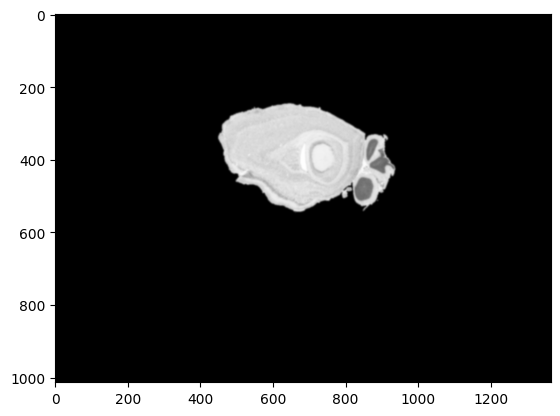

In [171]:
imgfile = sample(files,1)
imgpath = os.path.join(INPUT, imgfile[0])
img = imread(imgpath)
cleaned = mask_and_grey(img)
plt.imshow(cleaned, cmap="gray")

In [136]:
for file in files:
    inpath = os.path.join(INPUT, file)
    img = imread(inpath)
    cleaned = mask_and_grey(img)
    outpath = os.path.join(OUTPUT, file)
    imwrite(outpath, cleaned)


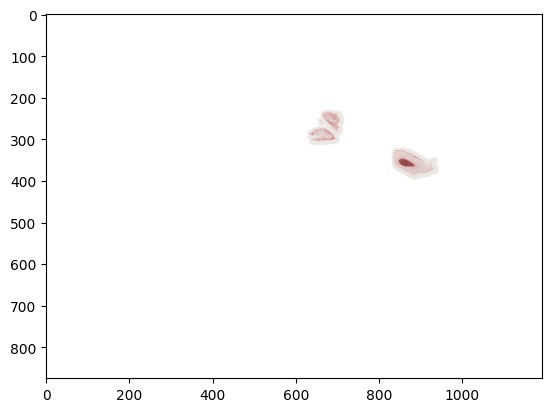

In [72]:
plt.imshow(img)

In [12]:

print(mask.dtype, mask.shape, mask.ndim)

uint8 (875, 1193) 2


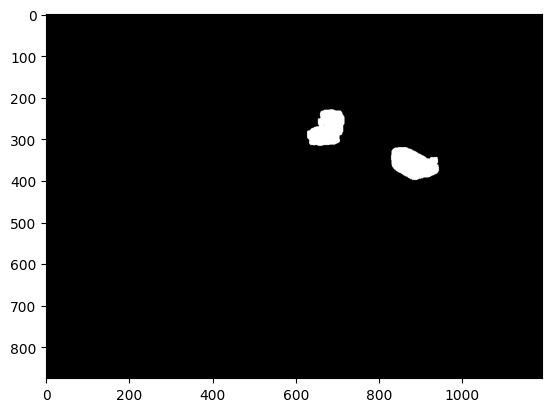

In [74]:
plt.imshow(mask, cmap='gray')

In [151]:
structure = 'Sp5C_L'
fbrains = {}
moving_brains = ['MD585', 'MD589', 'MD594']
fixed_brain = 'AtlasV8'
basepath = '/net/birdstore/Active_Atlas_Data/data_root/atlas_data'
for brain in moving_brains:
    com = np.loadtxt(os.path.join(basepath, brain, 'com', f'{structure}.txt'))
    fbrains[brain] = com.tolist()
    
for k,v in fbrains.items():
    print(k,v)
    
print(fbrains.values())
avg_fbrains = np.mean(list(fbrains.values()), axis=0)
print()
print(avg_fbrains)
fixed_brain_com = np.loadtxt(os.path.join(basepath, fixed_brain, 'com', f'{structure}.txt'))
print([f/25 for f in fixed_brain_com])

MD585 [14193.193749751725, 6253.760722913531, 3425.356928687692]
MD589 [14539.453457563834, 8198.833574137623, 3915.4234924526854]
MD594 [16154.634115714514, 5833.392159469067, 4106.670021386338]
dict_values([[14193.193749751725, 6253.760722913531, 3425.356928687692], [14539.453457563834, 8198.833574137623, 3915.4234924526854], [16154.634115714514, 5833.392159469067, 4106.670021386338]])

[14962.42710768  6761.99548551  3815.81681418]
[598.4970843070677, 270.4798194202696, 152.63267256702287]
